# **2012 Federal Election Commission Database**

## **Giới thiệu**

Dataset 2012 Federal Election Commission (FEC) ghi lại thông tin chi tiết về các khoản quyên góp cho các ứng viên tranh cử liên bang tại Hoa Kỳ. Dữ liệu bao gồm tên ứng viên, nghề nghiệp và nơi làm việc của người tài trợ, số tiền quyên góp, thời gian giao dịch và đảng phái chính trị. Đây là nguồn dữ liệu quan trọng để phân tích hành vi tài trợ, xu hướng chính trị và xây dựng các mô hình dự đoán.

**Input (dữ liệu đầu vào):**
| **Tên cột**            | **Ý nghĩa**                                      | **Loại dữ liệu** | **Vai trò**     |
|------------------------|--------------------------------------------------|------------------|-----------------|
| `cmte_id`              | Mã ủy ban vận động tranh cử                      | object           | Input           |
| `cand_id`              | Mã ứng viên                                      | object           | Input           |
| `cand_nm`              | Tên ứng viên                                     | object           | Input           |
| `contbr_nm`            | Tên người/tổ chức tài trợ                        | object           | Input           |
| `contbr_city`          | Thành phố người tài trợ                          | object           | Input           |
| `contbr_st`            | Bang người tài trợ                               | object           | Input           |
| `contbr_zip`           | Mã vùng người tài trợ                            | object           | Input           |
| `contbr_employer`      | Nơi làm việc của người tài trợ                   | object           | Input           |
| `contbr_occupation`    | Nghề nghiệp người tài trợ                         | object           | Input           |
| `contb_receipt_amt`    | Số tiền tài trợ nhận được                        | float64          | Input / Output* |
| `contb_receipt_dt`     | Ngày nhận tài trợ                                | object           | Input           |
| `receipt_desc`         | Mô tả giao dịch                                  | object           | Input           |
| `memo_cd`              | Mã ghi chú giao dịch                             | object           | Input           |
| `memo_text`            | Nội dung ghi chú                                 | object           | Input           |
| `form_tp`              | Loại biểu mẫu                                    | object           | Input           |
| `file_num`             | Số hiệu file                                     | int64            | Input           |

**Output (dữ liệu đầu ra):**
- Tổng số tiền quyên góp theo từng ứng viên (contb_receipt_amt)

- Tổng tiền quyên góp theo đảng phái (Democrat, Republican)

- Số lượng giao dịch tài trợ theo ứng viên hoặc đảng

- Phân bố tiền tài trợ theo nghề nghiệp người đóng góp

- Phân bố tiền tài trợ theo bang hoặc vùng địa lý

- Biểu đồ so sánh tài trợ giữa các ứng viên

- Danh sách ứng viên nhận nhiều tài trợ nhất


## **Mục đích của việc chuẩn hóa dữ liệu xuyên suốt bài làm:** 
Việc chuẩn hóa dữ liệu giúp làm sạch và đồng nhất thông tin, từ đó nâng cao độ chính xác khi phân tích.

- **Chuẩn hóa dữ liệu nghề nghiệp (`occ_mapping`)**
    - Gộp các cách viết khác nhau của cùng một nghề (ví dụ: `"C.E.O."` → `"CEO"`).
    - Loại bỏ các giá trị không rõ ràng hoặc thiếu thông tin bằng cách thay thế bằng `"NOT PROVIDED"`.

- **Chuẩn hóa tên ứng viên (`parties`)**
    - Gắn nhãn đảng phái cho từng ứng viên (Democrat hoặc Republican).
    - Giúp phân tích tài trợ theo đảng dễ dàng và chính xác hơn.

- **Chuẩn hóa dữ liệu chủ doanh nghiệp (`emp_mapping`)**
    - Chuẩn hóa các cách ghi "self-employed" để thống nhất thành `"SELF-EMPLOYED"`.
    - Loại bỏ các giá trị không đầy đủ bằng cách thay thế bằng `"NOT PROVIDED"`.

=> Việc chuẩn hóa này là bước quan trọng trước khi thực hiện thống kê, trực quan hóa hoặc xây dựng mô hình dự đoán.

## **Mục đích của việc tính tổng tiền quyên góp xuyên suốt bài làm:**
Tính tổng tiền quyên góp giúp xác định mức độ ủng hộ tài chính dành cho từng ứng viên theo từng nhóm (như tiểu bang hoặc khoảng quyên góp), từ đó so sánh, phân tích và trực quan hóa nguồn tài trợ một cách rõ ràng và có hệ thống. 

## **1. Đọc dữ liệu**

In [7]:
# Đọc file dữ liệu

import pandas as pd

fec = pd.read_csv("dataset/P00000001-ALL.csv", low_memory=False)

fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

In [8]:
# Chi tiết một bản ghi quyên góp

fec.iloc[123456]

cmte_id                             C00431445
cand_id                             P80003338
cand_nm                         Obama, Barack
contbr_nm                         ELLMAN, IRA
contbr_city                             TEMPE
contbr_st                                  AZ
contbr_zip                          852816719
contbr_employer      ARIZONA STATE UNIVERSITY
contbr_occupation                   PROFESSOR
contb_receipt_amt                        50.0
contb_receipt_dt                    01-DEC-11
receipt_desc                              NaN
memo_cd                                   NaN
memo_text                                 NaN
form_tp                                 SA17A
file_num                               772372
Name: 123456, dtype: object

## **2. Thống kê số lượng quyên góp bầu cử**

In [9]:
# Danh sách ứng viên trong dữ liệu FEC 2012

unique_cands = fec["cand_nm"].unique()

unique_cands

array(['Bachmann, Michelle', 'Romney, Mitt', 'Obama, Barack',
       "Roemer, Charles E. 'Buddy' III", 'Pawlenty, Timothy',
       'Johnson, Gary Earl', 'Paul, Ron', 'Santorum, Rick',
       'Cain, Herman', 'Gingrich, Newt', 'McCotter, Thaddeus G',
       'Huntsman, Jon', 'Perry, Rick'], dtype=object)

In [10]:
unique_cands[2]

'Obama, Barack'

### **2.1 Chuẩn hóa dữ liệu tên ứng viên:**

In [11]:
# Chuẩn hóa dữ liệu tên ứng viên

parties = {
    "Bachmann, Michelle": "Republican",
    "Cain, Herman": "Republican",
    "Gingrich, Newt": "Republican",
    "Huntsman, Jon": "Republican",
    "Johnson, Gary Earl": "Republican",
    "McCotter, Thaddeus G": "Republican",
    "Obama, Barack": "Democrat",
    "Paul, Ron": "Republican",
    "Pawlenty, Timothy": "Republican",
    "Perry, Rick": "Republican",
    "Roemer, Charles E. 'Buddy' III": "Republican",
    "Romney, Mitt": "Republican",
    "Santorum, Rick": "Republican"
}


In [12]:
# Trích xuất tên ứng viên từ một đoạn dữ liệu
fec["cand_nm"][123456:123461]

123456    Obama, Barack
123457    Obama, Barack
123458    Obama, Barack
123459    Obama, Barack
123460    Obama, Barack
Name: cand_nm, dtype: object

In [13]:
# Gán nhãn đảng phái cho một đoạn dữ liệu
fec["cand_nm"][123456:123461].map(parties)

123456    Democrat
123457    Democrat
123458    Democrat
123459    Democrat
123460    Democrat
Name: cand_nm, dtype: object

### **2.2 Thống kê số lượng quyên góp:**

In [14]:
# Thêm cột đảng phái và thực hiện thống kê số lượng quyên góp
fec["party"] = fec["cand_nm"].map(parties)

fec["party"].value_counts()

party
Democrat      593746
Republican    407985
Name: count, dtype: int64

**Nhận xét:** Dữ liệu FEC 2012 cho thấy số lượng quyên góp dành cho Đảng Dân chủ (Democrat) là 593.746 lượt, cao hơn so với 407.985 lượt của Đảng Cộng hòa (Republican). Việc sử dụng .map() giúp phân loại nhanh theo đảng phái, hỗ trợ trực quan hóa và phân tích xu hướng ủng hộ chính trị.

### **2.3 Kiểm tra số lượng quyên góp dương và âm:**

In [15]:
# Kiểm tra số lượng quyên góp dương và âm
(fec["contb_receipt_amt"] > 0).value_counts()

contb_receipt_amt
True     991475
False     10256
Name: count, dtype: int64

**Nhận xét:** Dữ liệu cho thấy có 991.475 khoản quyên góp có giá trị dương và 10.256 khoản không hợp lệ (bằng hoặc nhỏ hơn 0). Việc lọc bỏ các giá trị không dương là cần thiết để đảm bảo phân tích chính xác, tránh sai lệch khi thống kê tổng số tiền hoặc phân loại quy mô quyên góp. Đây là bước tiền xử lý quan trọng trong phân tích dữ liệu tài chính.


### **2.4 Lọc dữ liệu theo quyên góp dương:**

In [16]:
# Lọc dữ liệu chỉ giữ lại quyên góp dương
fec = fec[fec["contb_receipt_amt"] > 0]

fec.head()

,cmte_id,cand_id,cand_nm,contbr_nm,contbr_city,contbr_st,contbr_zip,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,receipt_desc,memo_cd,memo_text,form_tp,file_num,party
0,C00410118,P20002978,"Bachmann, Michelle","HARVEY, WILLIAM",MOBILE,AL,366010290,RETIRED,RETIRED,250.0,20-JUN-11,NaN,NaN,NaN,SA17A,736166,Republican
1,C00410118,P20002978,"Bachmann, Michelle","HARVEY, WILLIAM",MOBILE,AL,366010290,RETIRED,RETIRED,50.0,23-JUN-11,NaN,NaN,NaN,SA17A,736166,Republican
2,C00410118,P20002978,"Bachmann, Michelle","SMITH, LANIER",LANETT,AL,368633403,INFORMATION REQUESTED,INFORMATION REQUESTED,250.0,05-JUL-11,NaN,NaN,NaN,SA17A,749073,Republican
3,C00410118,P20002978,"Bachmann, Michelle","BLEVINS, DARONDA",PIGGOTT,AR,724548253,NONE,RETIRED,250.0,01-AUG-11,NaN,NaN,NaN,SA17A,749073,Republican
4,C00410118,P20002978,"Bachmann, Michelle","WARDENBURG, HAROLD",HOT SPRINGS NATION,AR,719016467,NONE,RETIRED,300.0,20-JUN-11,NaN,NaN,NaN,SA17A,736166,Republican


**Mục đích của việc lọc dữ liệu:** Lọc dữ liệu chỉ giữ lại các khoản quyên góp dương giúp loại bỏ các giao dịch không hợp lệ hoặc hoàn trả, đảm bảo kết quả phân tích phản ánh đúng số tiền tài trợ thực tế.

### **2.5 Tạo tập con gồm Obama và Romney:**

In [17]:
# Tạo tập con chỉ gồm Obama và Romney
fec_mrbo = fec[fec["cand_nm"].isin(["Obama, Barack", "Romney, Mitt"])]

fec_mrbo.head()

,cmte_id,cand_id,cand_nm,contbr_nm,contbr_city,contbr_st,contbr_zip,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,receipt_desc,memo_cd,memo_text,form_tp,file_num,party
411,C00431171,P80003353,"Romney, Mitt","ELDERBAUM, WILLIAM",DPO,AA,340230183,US GOVERNMENT,FOREIGN SERVICE OFFICER,25.0,01-FEB-12,NaN,NaN,NaN,SA17A,780124,Republican
412,C00431171,P80003353,"Romney, Mitt","ELDERBAUM, WILLIAM",DPO,AA,340230183,US GOVERNMENT,FOREIGN SERVICE OFFICER,110.0,01-FEB-12,NaN,NaN,NaN,SA17A,780124,Republican
413,C00431171,P80003353,"Romney, Mitt","CARLSEN, RICHARD",APO,AE,091280020,DEFENSE INTELLIGENCE AGENCY,INTELLIGENCE ANALYST,250.0,13-APR-12,NaN,NaN,NaN,SA17A,785689,Republican
414,C00431171,P80003353,"Romney, Mitt","DELUCA, PIERRE",APO,AE,091280005,CISCO,ENGINEER,30.0,21-AUG-11,NaN,NaN,NaN,SA17A,760261,Republican
415,C00431171,P80003353,"Romney, Mitt","SARGENT, MICHAEL",APO,AE,090120092,RAYTHEON TECHNICAL SERVICES CORP,COMPUTER SYSTEMS ENGINEER,100.0,07-MAR-12,NaN,NaN,NaN,SA17A,780128,Republican


**Mục đích của việc tạo tập con:** Tạo tập con chỉ gồm Obama và Romney giúp tập trung phân tích vào hai ứng viên nổi bật trong cuộc bầu cử năm 2012, từ đó dễ so sánh nguồn tài trợ, đặc điểm người ủng hộ và xu hướng chính trị giữa họ.

## **3. Thống kê theo nghề nghiệp và chủ doanh nghiệp**

In [18]:
# Thống kê số lượng người quyên góp theo nghề nghiệp

fec["contbr_occupation"].value_counts()[:10]

contbr_occupation
RETIRED                                   233990
INFORMATION REQUESTED                      35107
ATTORNEY                                   34286
HOMEMAKER                                  29931
PHYSICIAN                                  23432
INFORMATION REQUESTED PER BEST EFFORTS     21138
ENGINEER                                   14334
TEACHER                                    13990
CONSULTANT                                 13273
PROFESSOR                                  12555
Name: count, dtype: int64

### **3.1 Chuẩn hóa dữ liệu nghề nghiệp:**

In [19]:
# Chuẩn hóa dữ liệu nghề nghiệp

occ_mapping = {
    "INFORMATION REQUESTED PER BEST EFFORTS": "NOT PROVIDED",
    "INFORMATION REQUESTED": "NOT PROVIDED",
    "INFORMATION REQUESTED (BEST EFFORTS)": "NOT PROVIDED",
    "C.E.O.": "CEO"
}


### **3.2 Tạo hàm tùy chỉnh cho dữ liệu nghề nghiệp:**

In [20]:
# Chuẩn hóa dữ liệu nghề nghiệp bằng hàm tùy chỉnh

def get_occ(x):
    # If no mapping provided, return x
    return occ_mapping.get(x, x)

fec["contbr_occupation"] = fec["contbr_occupation"].map(get_occ)

**Tác dụng của hàm tùy chỉnh:** Chuẩn hóa dữ liệu nghề nghiệp bằng hàm giúp tự động thay thế các giá trị không đồng nhất hoặc không rõ ràng theo bảng ánh xạ (occ_mapping). Việc này đảm bảo dữ liệu nhất quán, dễ phân tích và tránh sai lệch khi thống kê theo nghề nghiệp.

### **3.3 Chuẩn hóa dữ liệu chủ doanh nghiệp:**

In [21]:
# Chuẩn hóa dữ liệu chủ doanh nghiệp

emp_mapping = {
    "INFORMATION REQUESTED PER BEST EFFORTS": "NOT PROVIDED",
    "INFORMATION REQUESTED": "NOT PROVIDED",
    "SELF": "SELF-EMPLOYED",
    "SELF EMPLOYED": "SELF-EMPLOYED",
}


### **3.4 Tạo hàm tùy chỉnh cho dữ liệu chủ doanh nghiệp:**

In [22]:
# Chuẩn hóa dữ liệu chủ doanh nghiệp bằng hàm tùy chỉnh

def get_emp(x):
    # If no mapping provided, return x
    return emp_mapping.get(x, x)

fec["contbr_employer"] = fec["contbr_employer"].map(get_emp)

### **3.5 Tạo bảng tổng hợp theo nghề nghiệp và đảng**

In [23]:
# Tạo bảng tổng hợp theo nghề nghiệp và đảng

by_occupation = fec.pivot_table("contb_receipt_amt",
                                index="contbr_occupation",
                                columns="party",
                                aggfunc="sum")

by_occupation.head(5)

party,Democrat,Republican
contbr_occupation,,
MIXED-MEDIA ARTIST / STORYTELLER,100.0,NaN
AREA VICE PRESIDENT,250.0,NaN
RESEARCH ASSOCIATE,100.0,NaN
TEACHER,500.0,NaN
THERAPIST,3900.0,NaN


**Mục đích tạo bảng:** Tạo bảng tổng hợp giúp so sánh tổng tiền quyên góp giữa các nghề nghiệp và đảng phái, từ đó dễ dàng phân tích xu hướng tài trợ chính trị theo từng nhóm nghề.

### **3.6 Lọc dữ liệu nghề nghiệp:**

In [36]:
# Lọc các nghề có tổng quyên góp > 2 triệu USD

over_2mm = by_occupation[by_occupation.sum(axis="columns") > 2000000]

# Hiển thị kết quả lọc

over_2mm

party,Democrat,Republican
contbr_occupation,,
ATTORNEY,11141982.97,7477194.43
CEO,2074974.79,4211040.52
CONSULTANT,2459912.71,2544725.45
ENGINEER,951525.55,1818373.70
EXECUTIVE,1355161.05,4138850.09
HOMEMAKER,4248875.80,13634275.78
INVESTOR,884133.00,2431768.92
LAWYER,3160478.87,391224.32
MANAGER,762883.22,1444532.37


**Mục đích của việc lọc dữ liêu:** Lọc các nghề có tổng quyên góp trên 2 triệu USD giúp tập trung phân tích vào những nhóm nghề nghiệp có ảnh hưởng tài chính lớn trong chiến dịch, loại bỏ các nhóm nhỏ lẻ để dễ so sánh và trực quan hóa.

**Nhận xét:** Bảng thống kê cho thấy các nghề nghiệp như Retired, Attorney, Homemaker, và Executive đóng góp số tiền lớn nhất cho cả hai đảng. Đáng chú ý, nhóm Retired dẫn đầu với hơn 25 triệu USD cho Đảng Dân chủ (Democrat) và hơn 23 triệu USD cho Đảng Cộng hòa (Republican). Một số nghề như CEO và Executive có xu hướng đóng góp nhiều hơn cho Đảng Cộng hòa, trong khi Attorney và Consultant nghiêng về Đảng Dân chủ. Việc phân tích theo nghề giúp hiểu rõ xu hướng ủng hộ chính trị từ các nhóm xã hội khác nhau.


### **3.7 Biểu đồ so sánh quyên góp theo nghề nghiệp và đảng phái**

<Axes: ylabel='contbr_occupation'>

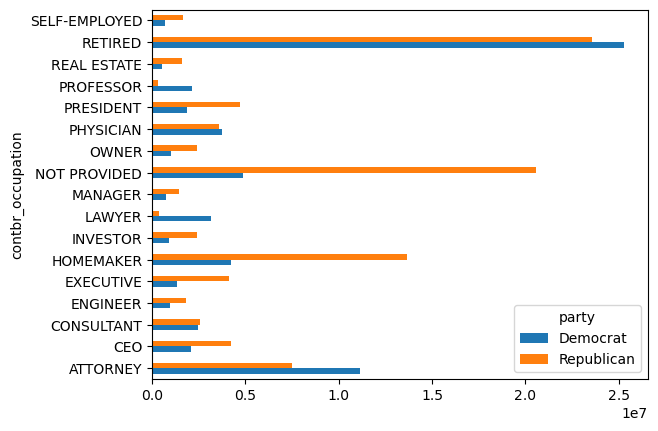

In [26]:
over_2mm.plot(kind="barh")

**Nhận xét:** Biểu đồ cho thấy các nhóm nghề nghiệp như "RETIRED", "SELF-EMPLOYED", và "NOT PROVIDED" đóng góp số tiền lớn nhất cho cả hai đảng. Một số nghề như "ATTORNEY" và "PROFESSOR" có xu hướng ủng hộ Đảng Dân chủ, trong khi "PHYSICIAN", "CEO" và "INVESTOR" nghiêng về Đảng Cộng hòa. Việc chuẩn hóa dữ liệu giúp làm rõ sự khác biệt trong hành vi quyên góp giữa các nhóm nghề.

### **3.8 Thực hiện tạo hàm tìm n nhóm theo một tiêu chí:**

In [37]:
# Hàm tìm n nhóm có tổng quyên góp cao nhất theo một tiêu chí (key)

def get_top_amounts(group, key, n=5):
    totals = group.groupby(key)["contb_receipt_amt"].sum()
    return totals.nlargest(n)

**Tác dụng của hàm:** Hàm này được tạo ra để tìm nhanh các nhóm (ví dụ: nghề nghiệp, công ty, thành phố…) có tổng số tiền quyên góp cao nhất. Nó giúp rút trích thông tin nổi bật từ dữ liệu, phục vụ phân tích và trực quan hóa.

### **3.9 Nhóm dữ liệu fec_mrbo theo tên ứng viên (cand_nm):**

In [39]:
# Tạo đối tượng grouped bằng cách nhóm dữ liệu fec_mrbo theo tên ứng viên (cand_nm)

grouped = fec_mrbo.groupby("cand_nm")

**Mục đích việc nhóm dữ liệu:**
Nhóm dữ liệu theo `cand_nm` giúp phân tích riêng biệt từng ứng viên, từ đó xác định các nghề nghiệp đóng góp nhiều nhất cho mỗi người. Việc này hỗ trợ so sánh cơ sở tài trợ giữa các ứng viên và hiểu rõ đặc điểm nhóm người ủng hộ họ.


### **3.10 Top nghề nghiệp có quyên góp nhiều nhất:**

In [40]:
# Áp dụng hàm để tìm top nghề nghiệp quyên góp

grouped.apply(get_top_amounts, "contbr_occupation", n=7)

C:\Users\ACER\AppData\Local\Temp\ipykernel_17584\856165894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts, "contbr_occupation", n=7)


cand_nm        contbr_occupation                     
Obama, Barack  RETIRED                                   25305116.38
               ATTORNEY                                  11141982.97
               INFORMATION REQUESTED                      4866973.96
               HOMEMAKER                                  4248875.80
               PHYSICIAN                                  3735124.94
               LAWYER                                     3160478.87
               CONSULTANT                                 2459912.71
Romney, Mitt   RETIRED                                   11508473.59
               INFORMATION REQUESTED PER BEST EFFORTS    11396894.84
               HOMEMAKER                                  8147446.22
               ATTORNEY                                   5364718.82
               PRESIDENT                                  2491244.89
               EXECUTIVE                                  2300947.03
               C.E.O.                            

**Nhận xét:** Cả hai ứng viên Obama và Romney nhận nhiều quyên góp từ nhóm Retired, lần lượt hơn 25 triệu và 23 triệu USD. Các nghề như Homemaker, Executive, CEO, và Consultant cũng đóng góp đáng kể. Nhiều bản ghi thuộc nhóm Information Requested cho thấy dữ liệu chưa được chuẩn hóa. Phân tích theo nghề giúp hiểu xu hướng ủng hộ từ các tầng lớp xã hội.



### **3.11 Top chủ doanh nghiệp có quyên góp nhiều nhất:**

In [28]:
# Áp dụng hàm để tìm top chủ doanh nghiệp quyên góp

grouped.apply(get_top_amounts, "contbr_employer", n=10)

C:\Users\ACER\AppData\Local\Temp\ipykernel_17584\3586118955.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_top_amounts, "contbr_employer", n=10)


cand_nm        contbr_employer                       
Obama, Barack  RETIRED                                   22694358.85
               SELF-EMPLOYED                             17080985.96
               NOT EMPLOYED                               8586308.70
               INFORMATION REQUESTED                      5053480.37
               HOMEMAKER                                  2605408.54
               SELF                                       1076531.20
               SELF EMPLOYED                               469290.00
               STUDENT                                     318831.45
               VOLUNTEER                                   257104.00
               MICROSOFT                                   215585.36
Romney, Mitt   INFORMATION REQUESTED PER BEST EFFORTS    12059527.24
               RETIRED                                   11506225.71
               HOMEMAKER                                  8147196.22
               SELF-EMPLOYED                     

**Nhận xét:**

- **Barack Obama:**
  - Nhóm RETIRED (người nghỉ hưu) đóng góp cao nhất với hơn 22 triệu USD, cho thấy sự ủng hộ mạnh từ nhóm cử tri cao tuổi.

  - Các nhóm SELF-EMPLOYED, NOT EMPLOYED, và HOMEMAKER cũng đóng góp đáng kể, phản ánh sự đa dạng trong nguồn tài trợ cá nhân.

  - Một số đóng góp đến từ MICROSOFT, cho thấy có sự ủng hộ từ giới công nghệ.

- **Mitt Romney:**
  - Nhóm INFORMATION REQUESTED PER BEST EFFORTS đóng góp cao nhất, nhưng tên này không rõ ràng — thường là dữ liệu chưa được chuẩn hóa, cần xử lý lại.

  - Nhóm RETIRED, HOMEMAKER, và SELF-EMPLOYED cũng đóng góp lớn, tương tự như Obama.

  - Có nhiều đóng góp từ các tổ chức tài chính lớn như CREDIT SUISSE, MORGAN STANLEY, GOLDMAN SACHS, BARCLAYS CAPITAL, và H.I.G. CAPITAL — phản ánh sự ủng hộ từ giới tài chính.

## **4. Phân loại quy mô quyên góp**

### **4.1 Tạo các khoảng phân loại quyên góp:**

In [ ]:
import numpy as np

# Tạo các khoảng phân loại quy mô quyên góp

bins = np.array([0, 1, 10, 100, 1000, 10000, 100_000, 1_000_000, 10_000_000])

**Mục đích việc tạo các khoảng:** Tạo các khoảng quyên góp giúp phân loại mức tài trợ thành nhóm nhỏ, vừa và lớn để dễ phân tích và trực quan hóa.

### **4.2 Phân loại các khoản quyên góp:**

In [42]:
# Phân loại từng khoản quyên góp vào các khoảng

labels = pd.cut(fec_mrbo["contb_receipt_amt"], bins)

# Kiểm tra kết quả phân loại

labels

411         (10, 100]
412       (100, 1000]
413       (100, 1000]
414         (10, 100]
415         (10, 100]
             ...     
701381      (10, 100]
701382    (100, 1000]
701383        (1, 10]
701384      (10, 100]
701385    (100, 1000]
Name: contb_receipt_amt, Length: 694282, dtype: category
Categories (8, interval[int64, right]): [(0, 1] < (1, 10] < (10, 100] < (100, 1000] < (1000, 10000] < (10000, 100000] < (100000, 1000000] < (1000000, 10000000]]

**Tác dụng của việc phân loại:** Phân loại từng khoản quyên góp vào các khoảng giúp chia dữ liệu thành nhóm giá trị cụ thể, từ đó dễ dàng phân tích, thống kê và trực quan hóa theo quy mô tài trợ (nhỏ, vừa, lớn). Đây là bước tiền xử lý quan trọng để hiểu rõ cấu trúc phân bố của các khoản đóng góp.

### **4.3 Nhóm dữ liệu theo ứng viên và khoảng quyên góp**

In [31]:
# Nhóm dữ liệu theo ứng viên và khoảng quyên góp

grouped = fec_mrbo.groupby(["cand_nm", labels])

C:\Users\ACER\AppData\Local\Temp\ipykernel_17584\3608181561.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = fec_mrbo.groupby(["cand_nm", labels])


**Mục đích của việc nhóm dữ liệu:** Nhóm dữ liệu theo ứng viên và khoảng quyên góp giúp phân tích số tiền tài trợ theo từng mức quy mô cho từng ứng viên. Việc này hỗ trợ so sánh xem ứng viên nào nhận nhiều tài trợ nhỏ lẻ hay từ các khoản lớn, từ đó hiểu rõ hơn về cơ cấu nguồn tài trợ của họ.

### **4.4 Thống kê số lượng quyên góp theo ứng viên và khoảng**

In [32]:
# Thống kê số lượng quyên góp theo ứng viên và khoảng

grouped.size().unstack(level=0)

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",493,77
"(1, 10]",40070,3681
"(10, 100]",372280,31853
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


**Nhận xét:** Dữ liệu cho thấy phần lớn quyên góp cho Obama nằm ở khoảng từ 10 đến 10.000 USD, đặc biệt là nhóm 1.000–10.000 USD với hơn 153.000 lượt. Romney cũng nhận nhiều ở khoảng này nhưng ít hơn đáng kể. Obama có số lượng quyên góp nhỏ (dưới 100 USD) cao hơn Romney, cho thấy ông nhận được sự ủng hộ rộng rãi từ các cá nhân quy mô nhỏ. Phân tích theo khoảng tiền giúp hiểu rõ cấu trúc tài trợ và mức độ phổ biến của từng ứng viên.

### **4.5 Tính tổng tiền quyên góp theo ứng viên và khoảng**

In [33]:
# Tính tổng tiền quyên góp theo ứng viên và khoảng

bucket_sums = grouped["contb_receipt_amt"].sum().unstack(level=0)

# Chuẩn hóa tổng tiền theo từng khoảng

normed_sums = bucket_sums.div(bucket_sums.sum(axis="columns"), axis="index")

# Kiểm tra bảng tỷ lệ phần trăm

normed_sums

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 1]",0.805182,0.194818
"(1, 10]",0.918767,0.081233
"(10, 100]",0.910769,0.089231
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(10000, 100000]",0.823120,0.176880
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


**Nhận xét:** Dữ liệu cho thấy Obama nhận phần lớn quyên góp từ các mức thấp (dưới 100 USD), trong khi Romney chiếm ưu thế ở các mức cao hơn, đặc biệt từ 1.000 USD trở lên. Điều này phản ánh sự khác biệt về cơ cấu người ủng hộ: Obama có nhiều đóng góp nhỏ từ cộng đồng rộng, còn Romney nhận nhiều từ các nhà tài trợ lớn. Phân tích tỷ lệ phần trăm giúp làm rõ xu hướng tài trợ theo quy mô.

### **4.6 Biểu đồ trực quan hóa xu hướng quyên góp theo quy mô**

<Axes: ylabel='contb_receipt_amt'>

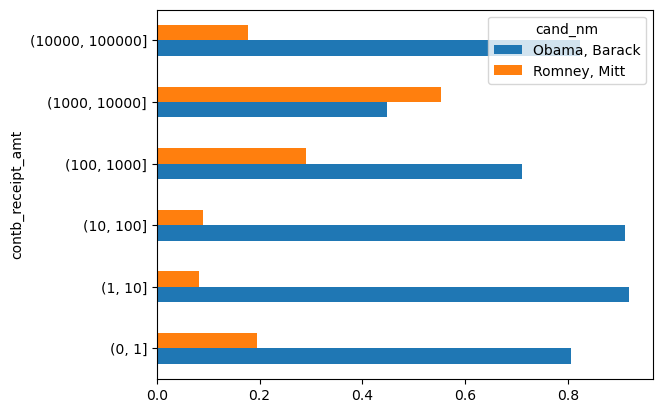

In [42]:
# loại bỏ 2 bucket lớn nhất vì đó là các khoản không phải từ cá nhân

normed_sums[:-2].plot(kind="barh")

**Nhận xét:** Biểu đồ cho thấy Barack Obama nhận được tỷ lệ quyên góp cao hơn ở các mức nhỏ (dưới $1.000), đặc biệt là trong các khoảng từ $0–$100. Ngược lại, Mitt Romney có tỷ lệ cao hơn ở các mức quyên góp lớn, đặc biệt từ $1.000 trở lên. Điều này phản ánh sự khác biệt trong cơ cấu người ủng hộ: Obama có nhiều nhà tài trợ nhỏ lẻ, còn Romney nhận được nhiều khoản lớn hơn từ ít người hơn.

## **5. Thống kê theo tiểu bang**

### **5.1 Nhóm dữ liệu theo ứng viên và tiểu bang:**

In [44]:
# Nhóm dữ liệu theo ứng viên và tiểu bang

grouped = fec_mrbo.groupby(["cand_nm", "contbr_st"])

**Mục đích của việc nhóm dữ liệu:** Nhóm dữ liệu theo ứng viên và tiểu bang giúp phân tích nguồn tài trợ theo khu vực địa lý, từ đó so sánh mức độ ủng hộ từng ứng viên tại các bang khác nhau. Đây là bước quan trọng để hiểu phân bố tài trợ trên toàn quốc.

### **5.2 Tính tổng tiền quyên góp theo ứng viên và tiểu bang:**

In [45]:
# Tính tổng tiền quyên góp và chuyển thành bảng

totals = grouped["contb_receipt_amt"].sum().unstack(level=0).fillna(0)

### **5.3 Lọc dữ liệu tổng quyên góp của các tiểu bang:**

In [ ]:
# Lọc các bang có tổng quyên góp > 100.000 USD

totals = totals[totals.sum(axis="columns") > 100000]

# Hiển thị 10 dòng đầu tiên của bảng tổng

totals.head(10)

**Mục đích của việc lọc dữ liệu:** Lọc các bang có tổng quyên góp trên 100.000 USD giúp tập trung phân tích vào những khu vực có ảnh hưởng tài chính lớn trong chiến dịch, loại bỏ các bang có đóng góp nhỏ để dễ so sánh và trực quan hóa.

**Nhận xét:** Dữ liệu cho thấy cả Obama và Romney đều nhận được quyên góp lớn từ các bang như California (CA), Florida (FL), và New York (NY). Obama nổi bật ở các bang như DC và California, trong khi Romney có thế mạnh tại Connecticut (CT) và Arizona (AZ). Việc lọc các bang có tổng quyên góp trên 100.000 USD giúp tập trung phân tích vào các khu vực có ảnh hưởng tài chính rõ rệt trong chiến dịch tranh cử.

### **5.4 Đổi tổng tiền quyên góp sang phần trăm:**

In [35]:
# Tính tỷ lệ phần trăm quyên góp của mỗi ứng viên trong từng bang

percent = totals.div(totals.sum(axis="columns"), axis="index")

# Hiển thị 10 dòng đầu tiên của bảng tỷ lệ

percent.head(10)

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(1, 10]",0.918767,0.081233
"(10, 100]",0.910769,0.089231
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


**Nhận xét:** Dữ liệu cho thấy Obama chiếm tỷ lệ quyên góp cao hơn ở hầu hết các bang như DC (81%), California (68%), và Delaware (80%), trong khi Romney vượt trội ở Connecticut (63%) và Arizona (56%). Phân tích tỷ lệ phần trăm giúp làm rõ mức độ ủng hộ tương đối giữa hai ứng viên theo từng bang.

## **6. Kết luận**